# Prototype clean copernicus 

In [34]:
import pandas as pd
import os

# Set

In [ ]:
year = 2024

#launch both the following products.
    # cmems_mod_med_phy-tem_anfc_4.2km_P1D-m
    # cmems_mod_med_bgc-pft_anfc_4.2km_P1D-m
product_name = 'cmems_mod_med_phy-tem_anfc_4.2km_P1D-m'
input_path = "data/raw"
df_name = f"{product_name}_{year}.parquet"

export_path = 'data/interim'
export_name = f"cleaned_{df_name}"
out = os.path.join(export_path, export_name)


# Import 

In [36]:
input = os.path.join(input_path, df_name)
df = pd.read_parquet(input)

# Check unique depth

In [37]:
df.head()

,depth,latitude,longitude,time,bottomT,thetao
0,1.018237,45.479168,13.166667,2024-01-01,13.325116,13.304394
1,1.018237,45.479168,13.166667,2024-01-02,13.248754,13.248711
2,1.018237,45.479168,13.166667,2024-01-03,13.210032,13.063446
3,1.018237,45.479168,13.166667,2024-01-04,13.120708,12.772483
4,1.018237,45.479168,13.166667,2024-01-05,13.103276,13.004619


In [38]:
if len(df['depth'].unique()) != 1:
    raise ValueError("DataFrame contains multiple depth levels.")

# Drop useless columns

In [39]:
df = df.drop(columns=['depth'])

# Rename columns 

In [40]:
rename_dict = {'time':'date'}
df = df.rename(columns=rename_dict)

In [41]:
df.head()

,latitude,longitude,date,bottomT,thetao
0,45.479168,13.166667,2024-01-01,13.325116,13.304394
1,45.479168,13.166667,2024-01-02,13.248754,13.248711
2,45.479168,13.166667,2024-01-03,13.210032,13.063446
3,45.479168,13.166667,2024-01-04,13.120708,12.772483
4,45.479168,13.166667,2024-01-05,13.103276,13.004619


# Filter only italian marine region

In [42]:
import matplotlib.pyplot as plt
bounds_df = pd.read_csv('data/raw/italy_marine_bounds.csv')
gulf_df = pd.read_csv('data/raw/ts_gulf_coords.csv')

In [43]:
unq_coords = df.drop_duplicates(subset=['latitude', 'longitude']).copy()

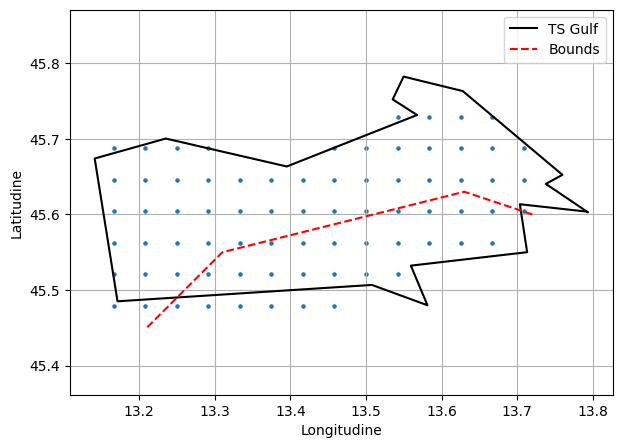

In [44]:
plt.figure(figsize=(7,5))

plt.plot(gulf_df['longitude'], gulf_df['latitude'], label = 'TS Gulf', color = 'black')
plt.plot(bounds_df['longitude'], bounds_df['latitude'], label = 'Bounds', color = 'red', linestyle='--')
plt.scatter(unq_coords['longitude'], unq_coords['latitude'], s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

In [45]:
import geopandas as gpd
from shapely.geometry import LineString, Point

def filter_above_boundary(df, bounds_df):
    # --- Boundary ---
    boundary_line = LineString(zip(bounds_df.longitude, bounds_df.latitude))

    # --- Ship points ---
    gdf = gpd.GeoDataFrame(
        df,
        geometry=[Point(xy) for xy in zip(df.longitude, df.latitude)]
    )

    def is_above_line(point, line):
        projection = line.interpolate(line.project(point))
        return point.y > projection.y

    gdf["above"] = gdf.geometry.apply(lambda p: is_above_line(p, boundary_line))

    filtered = gdf[gdf["above"]]
    
    return filtered.drop(columns=['geometry', 'above'])


In [46]:
filtered = filter_above_boundary(df, bounds_df)

In [47]:
fil_unq_coords = filtered.drop_duplicates(subset=['latitude', 'longitude']).copy()

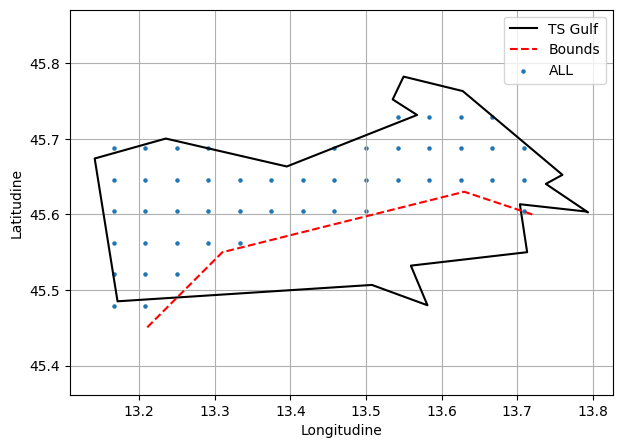

In [48]:
plt.figure(figsize=(7,5))

plt.plot(gulf_df['longitude'], gulf_df['latitude'], label = 'TS Gulf', color = 'black')
plt.plot(bounds_df['longitude'], bounds_df['latitude'], label = 'Bounds', color = 'red', linestyle='--')
plt.scatter(fil_unq_coords['longitude'], fil_unq_coords['latitude'], label = 'ALL', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

# Export 

In [49]:
filtered.to_parquet(out, index=False)